This notebook aims at estimating the convergence rate of the any algorithm with respect to $p$ or $q$. 

In [1]:
from pyPLNmodels.utils import build_block_Sigma, C_from_Sigma, sample_PLN, MSE, refined_MSE, MSE, log_stirling
import torch
#from fastPLNmodels.models import IMPS_PLN, log_likelihood, fastPLN, fastPLNPCA, PLNmodel
from pyPLNmodels.models import fastPLN,fastPLNPCA, IMPS_PLN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time 

Device  cuda
ok


In [2]:
import pyPLNmodels

In [3]:

import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.linalg as TLA
from tqdm import tqdm

from pyPLNmodels.utils import (C_from_Sigma, Poisson_reg, batch_log_P_WgivenY, init_C,
                    init_M, init_Sigma, log_stirling)
from pyPLNmodels.VRA import SAGARAD, SAGRAD, SVRGRAD

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else : 
    device = torch.device('cpu')
    
#device = torch.device('cpu') # think I can't use RTX A5000 right now, will check this later. 
torch.cuda.is_available()

True

In [5]:
%load_ext autoreload

%autoreload 2

In [7]:
d = 1
n = 100;  p = 20
q = 10

In [8]:
#torch.manual_seed(0)
Sigma_sampling = 1*torch.from_numpy(build_block_Sigma(p,q))/4 #+ 0.5*torch.eye(p)
true_C = C_from_Sigma(Sigma_sampling, q).to(device)
true_Sigma_sampling = true_C@(true_C.T)
true_beta =torch.randn((d, p), device = device )*0.75
covariates = torch.randn((n,d), device = device)/1
O =  1+torch.zeros((n,p), device = device)
Y, Z,_  = sample_PLN(true_C,true_beta, O, covariates)

In [10]:
torch.max(Y)

tensor(372., device='cuda:0')

In [11]:
Y = pd.DataFrame(Y.cpu().numpy())
covariates = pd.DataFrame(covariates.cpu().numpy())
O = pd.DataFrame(O.cpu().numpy())

<AxesSubplot:>

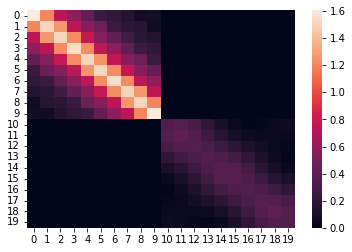

In [12]:
sns.heatmap(true_Sigma_sampling[:400,:400].cpu())

In [13]:
mypln = IMPS_PLN(q=q)
mypln.fit(Y,O,covariates, good_init = True, verbose = True, optimizer = torch.optim.Adagrad, N_iter_max = 500, lr = 0.01)

Intialization ...
Initalization done


  0%|▏                                                               | 1/500 [00:01<11:42,  1.41s/it]

Average log likelihood :  -57.695722063097286


  1%|▍                                                               | 3/500 [00:01<04:07,  2.01it/s]

Average log likelihood :  -57.344168535423044
Average log likelihood :  -57.17706813220641


...

Average log likelihood :  -54.98914212538909
 Criterion updated :  13 / 15


 17%|██████████▍                                                    | 83/500 [00:22<01:45,  3.96it/s]

Average log likelihood :  -55.074413466744375
 Criterion updated :  14 / 15


 17%|██████████▍                                                    | 83/500 [00:22<01:54,  3.65it/s]

Average log likelihood :  -55.080649259940344
 Criterion updated :  15 / 15
Algorithm stopped after  83  iterations


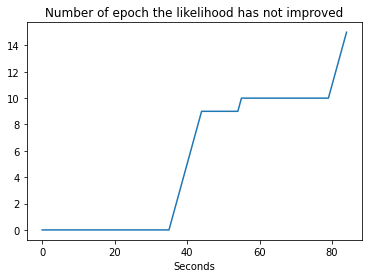

In [18]:
mypln.show_criterion()

qs : [ 2  5  8 11 14 17 20 23 26 29 32 35 38 41 44 47 50]
q :  2
Intialization ...
Initalization done


  1%|▍                                                               | 1/150 [00:02<06:18,  2.54s/it]

Average log likelihood :  -3992.826680387982


  1%|▊                                                               | 2/150 [00:04<05:39,  2.29s/it]

Average log likelihood :  -3970.0453627213847


...

Average log likelihood :  -3901.1908718114623
 Criterion updated :  38 / 1000


 99%|█████████████████████████████████████████████████████████████▌| 149/150 [04:23<00:01,  1.82s/it]

Average log likelihood :  -3901.3001924953514
 Criterion updated :  39 / 1000


100%|██████████████████████████████████████████████████████████████| 150/150 [04:25<00:00,  1.77s/it]

Average log likelihood :  -3901.282369171822
 Criterion updated :  40 / 1000
IMPS:
Best likelihood:  -3900.7762960772284
The heatmap only displays Sigma[:400,:400]


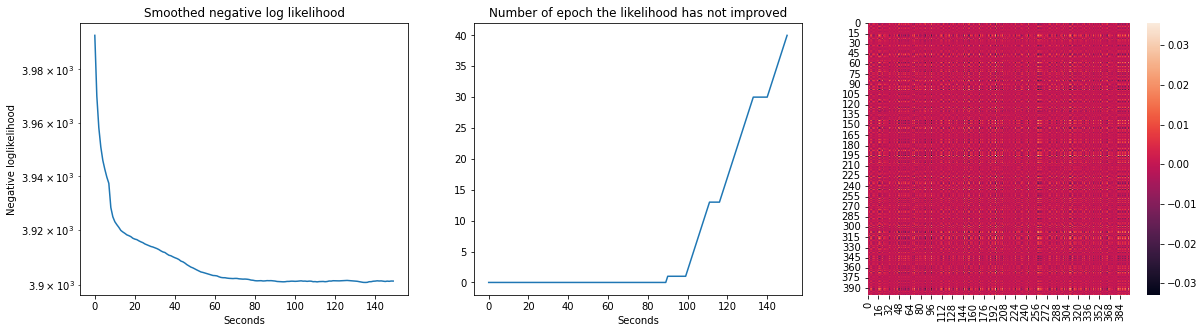

<Figure size 432x288 with 0 Axes>

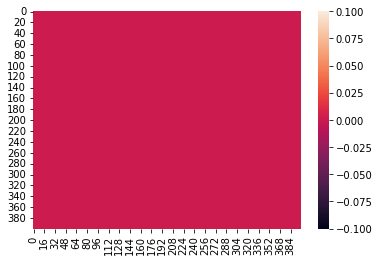

q :  5
Intialization ...
Initalization done


  1%|▍                                                               | 1/150 [00:02<05:47,  2.33s/it]

Average log likelihood :  -4023.0489874793902


  1%|▊                                                               | 2/150 [00:04<05:37,  2.28s/it]

Average log likelihood :  -3984.624533584507


...

Average log likelihood :  -3889.0311654503753
 Criterion updated :  57 / 1000


 99%|█████████████████████████████████████████████████████████████▌| 149/150 [04:31<00:01,  1.80s/it]

Average log likelihood :  -3889.2613019746173
 Criterion updated :  58 / 1000


100%|██████████████████████████████████████████████████████████████| 150/150 [04:33<00:00,  1.82s/it]

Average log likelihood :  -3889.2282434083936
 Criterion updated :  59 / 1000
IMPS:
Best likelihood:  -3888.64788847545
The heatmap only displays Sigma[:400,:400]


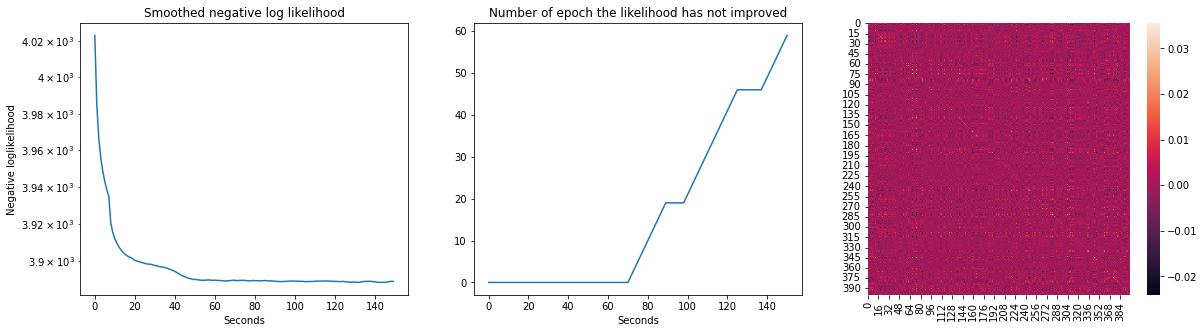

<Figure size 432x288 with 0 Axes>

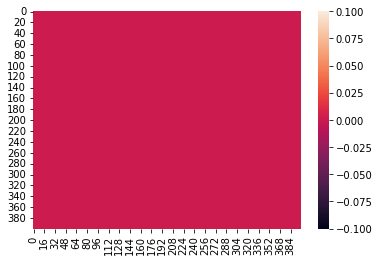

q :  8
Intialization ...
Initalization done


  1%|▍                                                               | 1/150 [00:02<05:49,  2.35s/it]

Average log likelihood :  -4038.7893253693974


  1%|▊                                                               | 2/150 [00:04<05:42,  2.31s/it]

Average log likelihood :  -3998.33285894335


...

Average log likelihood :  -3889.3018467228335


 99%|█████████████████████████████████████████████████████████████▌| 149/150 [04:48<00:01,  1.96s/it]

Average log likelihood :  -3889.30668700346


100%|██████████████████████████████████████████████████████████████| 150/150 [04:50<00:00,  1.94s/it]

Average log likelihood :  -3889.2310223340223
 Criterion updated :  26 / 1000
IMPS:
Best likelihood:  -3888.897429499687
The heatmap only displays Sigma[:400,:400]


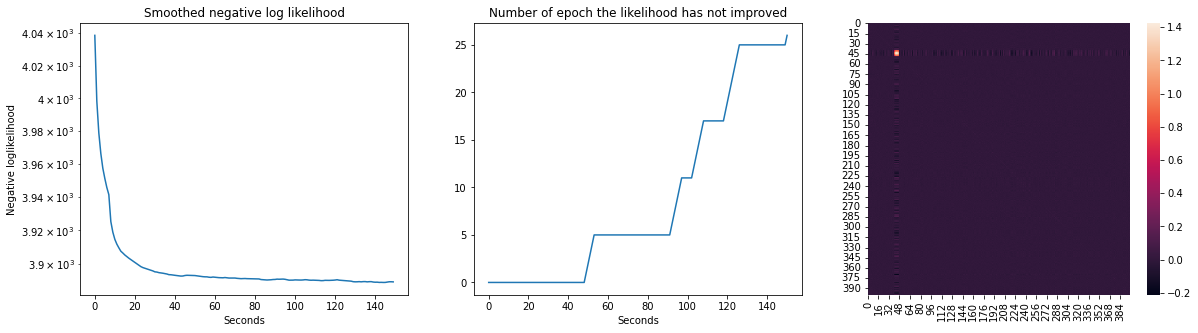

<Figure size 432x288 with 0 Axes>

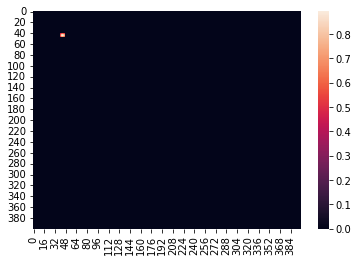

q :  11
Intialization ...
Initalization done


  1%|▍                                                               | 1/150 [00:02<06:16,  2.53s/it]

Average log likelihood :  -4048.120904425323


  1%|▊                                                               | 2/150 [00:04<06:05,  2.47s/it]

Average log likelihood :  -3995.9016204225036


...

Average log likelihood :  -3877.1927877194466
 Criterion updated :  9 / 1000


 64%|████████████████████████████████████████▎                      | 96/150 [03:15<01:46,  1.96s/it]

Average log likelihood :  -3877.3412097376445
 Criterion updated :  10 / 1000


 65%|████████████████████████████████████████▋                      | 97/150 [03:17<01:43,  1.95s/it]

Average log likelihood :  -3877.161844139485
 Criterion updated :  11 / 1000


In [ ]:
n = 300
d = 1
#p = 1000
p = 2000 
qs = np.linspace(2, 50, 17).astype(int)
#qs = [50]
#ps = np.linspace(10, 15000, 18).astype(int)
print('qs :', qs)

list_times_imps_q = []

for q in qs: 
    #torch.manual_seed(0)
    print('q : ', q)
    Sigma_sampling = 1*torch.from_numpy(build_block_Sigma(p,q))/4 #+ 0.5*torch.eye(p)
    true_C = C_from_Sigma(Sigma_sampling, q).to(device)
    true_Sigma_sampling = true_C@(true_C.T)
    true_beta =torch.randn((d, p), device = device )*0.75

    covariates = torch.randn((n,d), device = device)/1
    O =  1+torch.zeros((n,p), device = device)
    Y, _,_  = sample_PLN(true_C,true_beta, O, covariates)
    Y = pd.DataFrame(Y.cpu().numpy())
    covariates = pd.DataFrame(covariates.cpu().numpy())
    O = pd.DataFrame(O.cpu().numpy())
    
    imps =IMPS_PLN(q=q)
    imps.fit(Y,O,covariates, verbose = True, N_iter_max = 150, nb_plateau = 1000)
    print('IMPS:')
    print(imps)
    list_times_imps_q.append(imps.running_times[-1])
    sns.heatmap(true_Sigma_sampling[:400,:400].cpu())
    plt.show()
    
    

Device  cuda


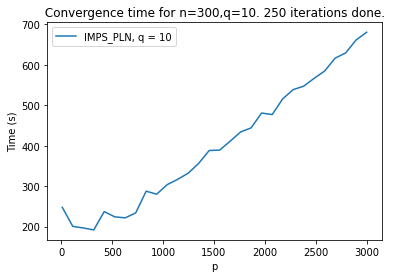

In [150]:
plt.plot(ps, list_times_imps, label = 'IMPS_PLN, q = '+ str(q))
plt.xlabel('p')
plt.ylabel('Time (s)')
plt.title(' Convergence time for n=300,q=10. 250 iterations done. ')
plt.legend()
#plt.savefig('Convergence_analysis_IMPS_PLN_n=300,q=10,250_iterations')

In [156]:
list_times_imps

[247.60059595108032,
 200.50440073013306,
 196.6485505104065,
 191.77661871910095,
 236.99540305137634,
 224.11884236335754,
 221.616473197937,
 233.78124046325684,
 287.53915548324585,
 280.0756673812866,
 303.8065104484558,
 316.93091678619385,
 332.03273248672485,
 356.35276055336,
 388.1026041507721,
 389.05917143821716,
 411.1727855205536,
 433.9818937778473,
 444.13548374176025,
 480.73319602012634,
 477.0237295627594,
 515.763251543045,
 538.5946891307831,
 547.1079080104828,
 566.5156352519989,
 584.5985128879547,
 616.4444603919983,
 629.1868653297424,
 661.3360669612885,
 680.5376958847046]

In [157]:
ps

array([  10,  113,  216,  319,  422,  525,  628,  731,  834,  937, 1041,
       1144, 1247, 1350, 1453, 1556, 1659, 1762, 1865, 1968, 2072, 2175,
       2278, 2381, 2484, 2587, 2690, 2793, 2896, 3000])

In [74]:
from fastPLNmodels.models import log_likelihood
from fastPLNmodels.utils import C_from_Sigma

new_C = C_from_Sigma(model.Sigma, p).detach()
print('log likelihood:', log_likelihood(Y,O,covariates, new_C, model.beta.detach()))

Intialization ...
Initalization done
log likelihood: tensor(-6.1016)
